Exact solution (reference): m = 1.5 , b = 1.4999999999999998

Final m: 1.3336
Final b: 1.8968
Final predictions: [3.2304 5.8976]


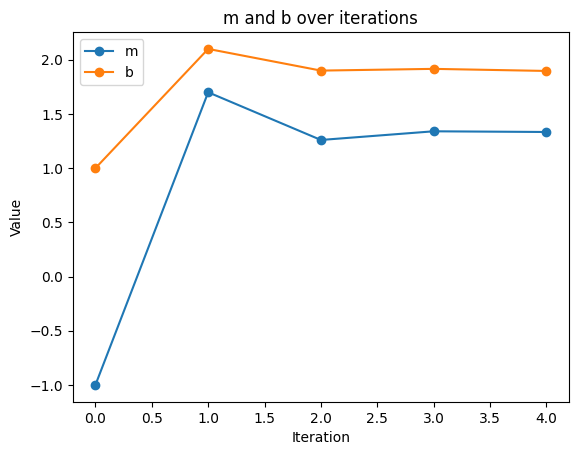

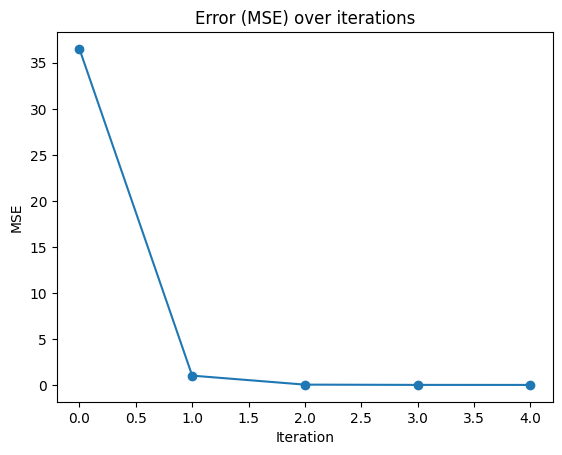

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import linalg

### Part 4
# Data points
x = np.array([1, 3], dtype=float)
y = np.array([3, 6], dtype=float)

# Initial values
m = -1.0
b = 1.0
alpha = 0.1
n = len(x)

m_history = [m]
b_history = [b]
mse_history = []

# MSE using SciPy linalg.norm
def mse_scipy(m, b):
    yhat = m*x + b
    errors = yhat - y
    # MSE = (1/n) * sum(errors^2) = (1/n) * ||errors||^2
    return (linalg.norm(errors) ** 2) / n

# Solve:
# [x1 1][m] = [y1]
# [x2 1][b]   [y2]
A = np.column_stack([x, np.ones_like(x)])
exact_m, exact_b = linalg.solve(A, y)
print("Exact solution (reference): m =", exact_m, ", b =", exact_b)

# Do iterations
for it in range(4):
    # 1) predictions
    yhat = m*x + b

    # 2) errors
    errors = yhat - y

    # 3) gradients (from MSE)
    dm = (2/n) * np.sum(errors * x)
    db = (2/n) * np.sum(errors)

    # record error before update (SciPy MSE)
    mse_history.append(mse_scipy(m, b))

    # 4) update (VISIBLE)
    m = m - alpha * dm
    b = b - alpha * db

    # store history
    m_history.append(m)
    b_history.append(b)

# record final mse too
mse_history.append(mse_scipy(m, b))

print("\nFinal m:", m)
print("Final b:", b)
print("Final predictions:", m*x + b)

# m and b over iterations
iters = np.arange(len(m_history))

plt.figure()
plt.plot(iters, m_history, marker="o", label="m")
plt.plot(iters, b_history, marker="o", label="b")
plt.xlabel("Iteration")
plt.ylabel("Value")
plt.title("m and b over iterations")
plt.legend()
plt.show()

# MSE over iterations
iters2 = np.arange(len(mse_history))

plt.figure()
plt.plot(iters2, mse_history, marker="o")
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.title("Error (MSE) over iterations")
plt.show()